## Тест

In [1]:
# import osmnx as ox
import pandas as pd
import geopandas as gpd
import networkx as nx
import numpy as np
import warnings
import sys
import os
warnings.filterwarnings("ignore")
sys.stderr = open(os.devnull, 'w')

# local crs
local_crs = 32636


from popframe.models.region import Region

region_model = Region.from_pickle('data/__popframe_model_cache__/3138.pkl')
# grid = gpd.read_file('/Users/mvin/Code/PopFrame/examples/data/level_3.geojson', engine="pyogrio")
# grid

In [2]:
region_model.get_towns_gdf()

,id,name,population,level,geometry
142986,142986,поселок Левашово,6021,Малый город,POINT (341711.772 6665064.098)
142987,142987,поселок Парголово,106155,Большой город,POINT (347403.123 6663896.586)
142988,142988,поселок Лисий Нос,6491,Малый город,POINT (332934.972 6656866.494)
142989,142989,город Колпино,143914,Большой город,POINT (366223.971 6626715.411)
142990,142990,поселок Металлострой,27313,Малый город,POINT (363133.806 6631474.889)
142991,142991,поселок Петро-Славянка,2090,Большое сельское поселение,POINT (359320.438 6632916.411)
142992,142992,поселок Понтонный,8588,Малый город,POINT (367148.879 6629443.681)
142993,142993,поселок Саперный,1638,Большое сельское поселение,POINT (370787.417 6628706.835)
142994,142994,поселок Усть-Ижора,2626,Большое сельское поселение,POINT (365044.468 6632236.014)
142995,142995,город Красное Село,58652,Средний город,POINT (336396.388 6624314.705)


In [ ]:
import requests
import geopandas as gpd

def fetch_hexagons(
    territory_id: int,
    centers_only: bool = False,
    base_url: str = ''
) -> gpd.GeoDataFrame:
    """
    Запрос гексагонов для заданного territory_id и возвращает их в виде GeoDataFrame.

    :param territory_id: ID территории
    :param centers_only: если True — вернуть только центральные точки гексагонов
    :param base_url: шаблон URL с {territory_id}
    :return: GeoDataFrame с колонками geometry, hexagon_id и свойствами
    """
    # Подставляем ID в URL
    url = base_url.format(territory_id=territory_id)
    params = {
        'centers_only': centers_only
    }

    # Выполняем запрос
    response = requests.get(url, params=params)
    response.raise_for_status()  # вызовет исключение, если код != 200

    # Парсим GeoJSON
    geojson = response.json()
    features = geojson.get('features', [])

    # Строим GeoDataFrame
    # from_features автоматически извлечёт geometry и все свойства
    gdf = gpd.GeoDataFrame.from_features(features)
    # Устанавливаем CRS (WGS84)
    gdf = gdf.set_crs(epsg=4326)

    return gdf

territory_id = 3138  # ID территории для Санкт-Петербурга
gdf_hex = fetch_hexagons(territory_id, centers_only=False)
gdf_hex

,geometry,hexagon_id,properties
0,"POLYGON ((30.06574 59.6709, 30.07379 59.67194,...",157558,{}
1,"POLYGON ((30.0877 60.08939, 30.09047 60.09382,...",157559,{}
2,"POLYGON ((30.37948 59.7927, 30.38759 59.79372,...",157560,{}
3,"POLYGON ((30.66727 59.76362, 30.66198 59.76704...",157561,{}
4,"POLYGON ((30.24918 60.02467, 30.25198 60.0291,...",157562,{}
...,...,...,...
2529,"POLYGON ((30.45791 60.02272, 30.46608 60.02376...",160087,{}
2530,"POLYGON ((30.23231 59.84322, 30.23764 59.83983...",160088,{}
2531,"POLYGON ((29.50097 60.20315, 29.49286 60.20206...",160089,{}
2532,"POLYGON ((30.74536 59.757, 30.74007 59.76043, ...",160090,{}


In [5]:
from popframe.method.territory_evaluation import TerritoryEvaluation

evaluation = TerritoryEvaluation(region=region_model)

results = evaluation.population_criterion(territories_gdf=gdf_hex,towns_gdf=towns)
scores_df = pd.DataFrame(results)
scores_df

,project,average_population_density,total_population,score,interpretation
0,None,27.8,58652,4.0,Территория имеет хорошие показатели численност...
1,None,84.7,178639,5.0,Территория с высокими показателями численности...
2,None,131.8,277986,5.0,Территория с высокими показателями численности...
3,None,151.3,319147,5.0,Территория с высокими показателями численности...
4,None,2733.2,5765496,5.0,Территория с высокими показателями численности...
...,...,...,...,...,...
2529,None,2653.4,5597763,5.0,Территория с высокими показателями численности...
2530,None,2661.4,5612122,5.0,Территория с высокими показателями численности...
2531,None,9.1,19115,3.0,Территория имеет показатели численности и плот...
2532,None,87.3,184079,5.0,Территория с высокими показателями численности...


In [6]:
gdf_hex['score'] = scores_df['score']
gdf_hex

,geometry,hexagon_id,properties,score
0,"POLYGON ((30.06574 59.6709, 30.07379 59.67194,...",157558,{},4.0
1,"POLYGON ((30.0877 60.08939, 30.09047 60.09382,...",157559,{},5.0
2,"POLYGON ((30.37948 59.7927, 30.38759 59.79372,...",157560,{},5.0
3,"POLYGON ((30.66727 59.76362, 30.66198 59.76704...",157561,{},5.0
4,"POLYGON ((30.24918 60.02467, 30.25198 60.0291,...",157562,{},5.0
...,...,...,...,...
2529,"POLYGON ((30.45791 60.02272, 30.46608 60.02376...",160087,{},5.0
2530,"POLYGON ((30.23231 59.84322, 30.23764 59.83983...",160088,{},5.0
2531,"POLYGON ((29.50097 60.20315, 29.49286 60.20206...",160089,{},3.0
2532,"POLYGON ((30.74536 59.757, 30.74007 59.76043, ...",160090,{},5.0


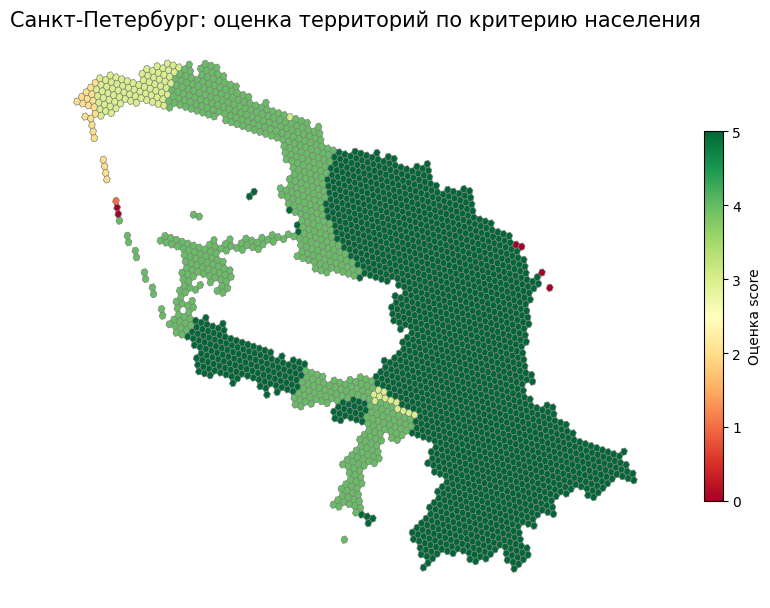

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt

# допустим, ваш GeoDataFrame называется gdf и в нём есть колонки 'geometry' и 'score'
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

gdf_hex.plot(
    column='score',          # раскраска по score
    cmap='RdYlGn',           # палитра от Red → Yellow → Green
    linewidth=0.5,           # толщина границ
    edgecolor='grey',        # цвет границ
    legend=True,             # вывод легенды
    legend_kwds={
        'label': "Оценка score",
        'shrink': 0.6
    },
    ax=ax
)

ax.set_title("Санкт-Петербург: оценка территорий по критерию населения", fontsize=15)
ax.set_axis_off()  # убираем оси

plt.show()



In [9]:
# grid.to_file("grid_population_score.geojson", driver="GeoJSON")

In [8]:
from popframe.method.territory_evaluation import TerritoryEvaluation

evaluation = TerritoryEvaluation(region=region_model)

results = evaluation.evaluate_territory_location(territories_gdf=gdf_hex)
scores_df = pd.DataFrame(results)
scores_df

,territory,score,interpretation,closest_settlement,closest_settlement1,closest_settlement2
0,None,0,Территория находится за границей агломерации,None,None,None
1,None,5,Территория находится внутри или непосредственн...,поселок Левашово,None,None
2,None,7,Территория находится внутри или непосредственн...,поселок Шушары,None,None
3,None,7,Территория находится внутри или непосредственн...,город Колпино,None,None
4,None,1,Территория находится между основными ядрами си...,None,поселок Парголово,поселок Лисий Нос
...,...,...,...,...,...,...
2529,None,0,Территория находится за границей агломерации,None,None,None
2530,None,1,Территория находится между основными ядрами си...,None,поселок Стрельна,поселок Александровская
2531,None,3,Территория находится внутри или непосредственн...,поселок Молодежное,None,None
2532,None,3,Территория находится внутри или непосредственн...,поселок Саперный,None,None


In [9]:
gdf_hex['score_2'] = scores_df['score']
gdf_hex

,geometry,hexagon_id,properties,score,score_2
0,"POLYGON ((30.06574 59.6709, 30.07379 59.67194,...",157558,{},4.0,0
1,"POLYGON ((30.0877 60.08939, 30.09047 60.09382,...",157559,{},5.0,5
2,"POLYGON ((30.37948 59.7927, 30.38759 59.79372,...",157560,{},5.0,7
3,"POLYGON ((30.66727 59.76362, 30.66198 59.76704...",157561,{},5.0,7
4,"POLYGON ((30.24918 60.02467, 30.25198 60.0291,...",157562,{},5.0,1
...,...,...,...,...,...
2529,"POLYGON ((30.45791 60.02272, 30.46608 60.02376...",160087,{},0.0,0
2530,"POLYGON ((30.23231 59.84322, 30.23764 59.83983...",160088,{},3.0,1
2531,"POLYGON ((29.50097 60.20315, 29.49286 60.20206...",160089,{},3.0,3
2532,"POLYGON ((30.74536 59.757, 30.74007 59.76043, ...",160090,{},5.0,3


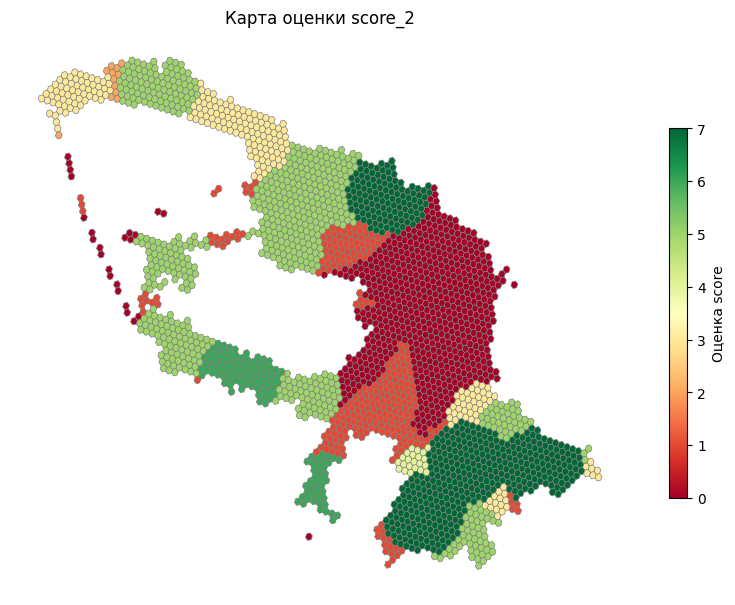

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt

# допустим, ваш GeoDataFrame называется gdf и в нём есть колонки 'geometry' и 'score'
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

gdf_hex.plot(
    column='score_2',          # раскраска по score
    cmap='RdYlGn',           # палитра от Red → Yellow → Green
    linewidth=0.5,           # толщина границ
    edgecolor='grey',        # цвет границ
    legend=True,             # вывод легенды
    legend_kwds={
        'label': "Оценка score",
        'shrink': 0.6
    },
    ax=ax
)

ax.set_title("Карта оценки score_2")
ax.set_axis_off()  # убираем оси

plt.show()
